# Notebook \#6: Machine Teaching for XAI
#### by Sebastian Einar Salas Røkholt

---

**Summary**  
This notebook operationalises Machine Teaching for Explainable AI (MT4XAI) on EV-charging time series. The goal of our simplified-example-based approach to MT4XAI is to help participants efficiently form an accurate mental model of the time series classifier from a *small* set of automatically selected and simplified examples. In this notebook, we load the trained classifier and session data, compute an **ORS** pool of robust piece-wise linear simplifications (k-segment curves that preserve the model’s label), bin the pool by class and k to control curriculum difficulty, select a compact, diverse **teaching set** $S$ using a facility-location objective with fidelity/robustness terms, and serve grouped teaching sessions with the original power curve + the simplified power curve and simplified SOC overlays for the upcoming study (two experimental groups + control group). We also construct exam sets for the study. 

---

**Index**  
- [**1 - Introduction and Setup**](#1---introduction-and-setup)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Load the Forecasting Model*](#12-load-the-forecasting-model)  
  - [*1.3 Data Preparation*](#13-data-preparation)  
- [**2 - Computing the Teaching Pool**](#2---computing-the-teaching-pool)  
  - [*2.1 - Running the pool constructor*](#21---running-the-pool-constructor)  
  - [*2.2 - Pool summary and diagnostics*](#22---pool-summary-and-diagnostics)  
  - [*2.3 - Binning the pool by class and k*](#23---binning-the-pool-by-class-and-k)  
- [**3 - Constructing the teaching set S**](#3---constructing-the-teaching-set-s)  
  - [*3.1 - Selection budget*](#31---selection-budget)  
  - [*3.2 - Teaching set selection*](#32---teaching-set-selection)  
- [**4 - The Teaching Session: Serving examples from the teaching set**](#teaching)  
  - [*Serving examples from the teaching set*](#4---serving-examples-from-the-teaching-set)  

---

**Introduction: Machine Teaching for XAI (MT4XAI)**  
Traditional post-hoc XAI for time series often struggles with human comprehensibility, and doubly so for time series classifiers as time series are notoriously difficult for humans to interpret. MT4XAI reframes example-based XAI techniques as *teaching*: the machine teaching system (teacher) selects a *small* set of examples (a.k.a. "witnesses") s.t. a human (learner) can reconstruct an accurate mental model of the black-box AI's behaviour.

In this project, example complexity is controlled by **Optimal Robust Simplifications (ORS)**: for each session we compute a piece-wise linear simplification with k segments that (i) stays close to the original curve, (ii) keeps the model's decision, and (iii) is robust to local perturbations. ORS admits a principled balance between error, simplicity (k), and robustness, with a polynomial-time algorithm under mild conditions. These simplifications intend to make the salient shape cues apparent to non-experts while preserving decision-relevant shapes/structure. 

We then assemble a teaching set S from a class-balanced "pool" of pre-computed simplifications using machine teaching principles. Rather than showing arbitrary cases, we optimise for a compact subset that best "covers" the model’s behaviours, enabling simulate-the-model tasks in the user study. Prior MT4XAI studies show that machine-selected witness sets can teach target behaviours more effectively than random sampling, and that accounting for human priors and representation choices matters. This notebook instantiates those ideas for multivariate charging sessions (power + SOC overlays) and prepares trial groups A/B/C for the study: 
 - Group A receives original `power`, simplified `power` and simplified `soc` ordered by simplicity/difficulty
 - Group B receives the same teaching set as group A but in random order
 - Group C receives the same teaching set as B but without simplifications (original `power` and `soc`).

**References & Background Literature:**
- [Optimal Robust Simplifications for Explaining Time Series Classifications](https://xai.w.uib.no/files/2024/07/ORS.pdf) (2024) by Telle, Ferri & Håvardstun.
- [XAI with Machine Teaching when Humans Are (Not) Informed about the Irrelevant Features](https://doi.org/10.1007/978-3-031-43418-1_23) (2023) by Håvardstun, Ferri, Hernández-Orallo, Parviainen & Telle. 
- [When Redundancy Matters: Machine Teaching of Representations](https://arxiv.org/pdf/2401.12711.pdf) (2024) by Ferri, Garigliotti, Håvardstun, Hernandez-Orallo & Telle.
- [XAI with Machine Teaching when Humans Are (Not) Informed about the Irrelevant Features](https://doi.org/10.1007/978-3-031-43418-1_23) (2023) by Håvardstun, Ferri, Hernandez-Orallo, Parviainen & Telle. 


## 1 - Setup
This notebook uses a class-based API defined in the project's custom Python package named `mt4xai`. In its modules named `teach` and `data`, we find these classes:
- `ChargingSession` contains the original, dense, unscaled arrays for the `power` series (and optionally for other channels/features as well). 
- `ChargingSessionSimplification` with knots\* only (indices + values). We cnvert these to dense simplifications and fetch original raw series on demand.
- `TeachingPool` owns the pool (`pool.parquet`), binning, and paths.
- `TeachingSet` performs selection with greedy facility-location (+ lazy pruning), then exposes A/B/C samplers.

Note: 
A *knot* is an endpoint of a straight line segment in the simplification. We define **k = number of straight line segments = knots − 1**.

In [1]:
# Standard lib + Pypi libs
import os
import sys
import json
import torch
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.figure import Figure, Axes
import seaborn as sns 

# project config
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(str(Path.cwd().parent))  # Adds additional scripts (e.g. project_config.py) in parent dir to path
from project_config import load_config
cfg = load_config()

# Modules from the project's MT4XAI package
%load_ext autoreload
%autoreload 2

# Pandas config
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)

# Path config
PROJECT_ROOT = Path(PROJECT_ROOT)
MODEL_FP = PROJECT_ROOT / cfg.paths.final_model
DATA_DIR = PROJECT_ROOT / cfg.paths.data_dir
DATASET_FP = Path(cfg.paths.dataset)
TEACHING_POOL_DIR = DATA_DIR / "teaching_pool"
EXAM_POOL_DIR = DATA_DIR / "exam_teaching_pool"
POOL_PATH = TEACHING_POOL_DIR / "pool.parquet"
EXAM_POOL_PATH = EXAM_POOL_DIR / "pool.parquet"
SAMPLE_PLAN = TEACHING_POOL_DIR / "sampled_normals.json"
EXAM_SAMPLE_PLAN = EXAM_POOL_DIR / "sampled_normals.json"
BINS_META_PATH = TEACHING_POOL_DIR / "bins_meta.json"
FIG_DIR = PROJECT_ROOT / "Figures"
TEACHING_SET_DIR = FIG_DIR / "teaching_sets"
EXAM_SET_DIR = FIG_DIR / "exam_sets"

for directory in [TEACHING_POOL_DIR, TEACHING_SET_DIR, TEACHING_SET_DIR, EXAM_SET_DIR]: 
    Path(directory).mkdir(parents=True, exist_ok=True)

# constants / tunable knobs
DEVICE = torch.device(cfg.project.device)
print("Device: ", DEVICE)
RANDOM_SEED = int(cfg.project.random_seed)
AD_THRESHOLD = float(cfg.inference.ad_rmse_threshold)
TEACHING_SET_EX_PER_CLS = 30  # 60 examples in teaching session
EXAM_SET_EX_PER_CLS = 20  # 40 examples spread across two exams (pre-teach + post-teach)

CONFIG FILE LOADED: 
{'project': {'random_seed': 42, 'root_dir': None}, 'paths': {'data_dir': 'Data', 'dataset': 'Data/etron55-charging-sessions.parquet', 'teaching_pool': 'Data/teaching_pool', 'models': 'Models', 'final_model': 'Models/final/final_model.pth', 'figures': 'Figures', 'logs': 'Logs'}, 'inference': {'horizon': 5, 'final_model_name': 'final_model.pth', 'hidden_dim': 256, 'num_layers': 4, 'dropout': 0.0027575414563, 'alpha_h': 0.5187590357622, 'batch_size': 32, 'grad_clip_norm': 5.0, 'lr': 0.000501551534, 'weight_decay': 1.1078448e-06, 'horizon_decay_lambda': 0.4, 't_min_eval': 1, 'ad_rmse_threshold': 13.3423, 'ad_pct_threshold': 95, 'metric': 'macro_rmse'}, 'ors': {'soc_stage1_mode': 'rdp', 'soc_rdp_epsilon': 0.75, 'soc_rdp_candidates': 5, 'soc_rdp_eps_min': 1e-06, 'soc_rdp_eps_max': 100.0, 'stage2_err_metric': 'l2', 'epsilon_mode': 'fraction'}, 'teaching': {'teaching_pool_dir': '../Data/teaching_pool', 'teaching_set_size': 60}}
Device:  cuda


### 1.2 Load the Forecasting Model
Here we load the LSTM forecasting model trained in the `03__Modelling.ipynb` notebook along with hyperparamters and some constants required to run inference on new data. 

In [2]:
# load model and hyperparams from Ray Tune checkpoint
from mt4xai.model import load_lstm_model

model, ckpt = load_lstm_model(MODEL_FP, device=DEVICE)
input_features  = ckpt["input_features"]
target_features = ckpt["target_features"]
H = int(ckpt["config"]["horizon"])  # forecast horizon
idx_power_inp = input_features.index("power")
idx_soc_inp = input_features.index("soc")
print(f"Loaded pretrained forecasting model {model}")

/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/src/mt4xai/model.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

Loaded pretrained forecasting model MultiHorizonLSTM(
  (lstm): LSTM(12, 256, num_layers=4, batch_first=True, dropout=0.0027575414563)
  (linear): Linear(in_features=256, out_features=5, bias=True)
)


### 1.3 Data Preparation
In this section, we will load, transform, and split the data in exactly the same way as we did previously in order to extract the test set, which we will use as a starting point for building the teaching set $S$. 

In [3]:
# load and scale data (identical to previous notebooks)
from mt4xai.data import apply_scalers, build_loader, fit_scalers_on_train, split_data

df = pd.read_parquet(DATASET_FP)
drop_cols = [c for c in [
    "energy","charger_category","timestamp","nearest_weather_station",
    "timestamp_d","lat","lon","timestamp_H"
] if c in df.columns]
df = df.drop(columns=drop_cols).copy()

train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1, random_seed=RANDOM_SEED)  # exact same split as before
scalers = fit_scalers_on_train(train_df, list(set(input_features) | set(target_features)))
power_scaler, soc_scaler = scalers["power"], scalers["soc"]
val_s = apply_scalers(val_df, scalers)
test_s = apply_scalers(test_df, scalers)

val_loader = build_loader(val_s, input_features, target_features, H, 
                          batch_size=32, shuffle=False, num_workers=8)

test_loader = build_loader(test_s, input_features, target_features, H,
                           batch_size=32, shuffle=False, num_workers=8)

print(f"There are {len(val_loader.dataset.groups)} charging sessions in the validation set")
print(f"There are {len(test_loader.dataset.groups)} charging sessions in the test set")

There are 6092 charging sessions in the validation set
There are 12183 charging sessions in the test set


### 2 - Computing the Teaching Pool
The Teaching Pool is a relatively large collection of examples that have been sampled (charging sessions / examples) from the validation set. By definition of the 95th percentile anomaly detection threshold, 95% of the charging sessions in the val set are normal while only 5% are abnormal. However, we want the teaching set to have an equal class distribution, so as an intermediate step we will compute a "teaching pool" that contains all abnormals and a random sampling of an equal number of normals. This is strategy is reasonable because there is less variation among normals than for abnormals. We then compute ORS for all sessions in the teaching pool. 

#### 2.1 - Running the pool constructor
Constructing the pool of simplifications + raw sessions is very computationally intensive, since to calculate the ORS simplifications for `power` we need to run model inference thousands of times per simplification. The teaching set contains 586 abnormals, so we will compute over a thousand ORS simplifications for `power` in our teaching pool. Additionally, we calculate ORS simplifications for `SOC`. We drastically reduce the computational effort for `SOC` simplifications by employing the Ramer-Douglas-Pecker simplification algorithm for generating stage-1 candidates for ORS, as opposed to the `power` simplifications which use dynamic programming with prefix sums. This is acceptable because the `SOC` feature has low importance towards determining the anomaly detection system's classification of the charging session. In contrary to `power`, `SOC` is a monotonically increasing and linear curve so we expect `k` ∈ [1, 3] even with RDP for ORS stage 1. </br>

The `mt4xai` API let's us load an existing pool (from the file `pool.parquet`) or construct it from scratch. Construction runs inference + ORS + embedding and writes the SQLite cache and the Parquet snapshot.

In [4]:
# loads an existing pool if available, otherwise build from scratch
from mt4xai.ors import ORSParams
from mt4xai.teach import TeachingPool, TeachingPoolConfig

construct_pool = False  # if False, will look for existing pool and resume existing/start from scratch if not complete

# configures the teaching pool and ORS parameters
tpconfig = TeachingPoolConfig(
    model_path=MODEL_FP,  # a pre-trained "black box" (multivariate LSTM) model
    output_dir=TEACHING_POOL_DIR,
    ad_threshold=AD_THRESHOLD,  # e.g. 13.3423, i.e. the 95th percentile Macro-RMSE on validation set
    random_seed=RANDOM_SEED,
    length_range=(11, 60),  # only samples sequences in range [min_T, max_T]
    device=DEVICE,
    export_every=10,
    L=128, P=4,   # for embeddings 
    decay_lambda=cfg.inference.horizon_decay_lambda,
    ors_params=ORSParams(
        stage1_mode="dp_prefix", 
        stage2_err_metric="rmse",
        dp_q=300,
        rdp_stage1_candidates=50,
        dp_alpha=0.0075, 
        beta=4.0, 
        gamma=0.05,
        R=3500,
        epsilon_mode="fraction", 
        epsilon_value=0.2,
        t_min_eval=2, 
        anchor_endpoints="last", 
        min_k=1, max_k=12, 
        random_seed=RANDOM_SEED,
        soc_stage1_mode="rdp", 
        soc_rdp_epsilon=0.75,
        model_id=MODEL_FP,
    )
)

# helper: read sampling plan and get target counts
def _sampling_plan_counts(path: Path) -> tuple[int, int] | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        plan = json.load(f)
    if "target" in plan:
        t = plan["target"]
        return int(t.get("abnormal", 0)), int(t.get("normal", 0))
    # fallback: infer balanced target
    n_abn = len(plan.get("abnormal", []))
    n_norm_all = len(plan.get("normal", []))
    return n_abn, min(n_norm_all, n_abn)


if POOL_PATH.exists():
    print("Loaded previously computed teaching pool from disk")
    pool = TeachingPool.load_from_parquet(POOL_PATH, config=tpconfig)
    n_current_abn = int((pool.pool_df["label_int"] == 1).sum())
    n_current_norm = int((pool.pool_df["label_int"] == 0).sum())
    print(f"Current pool counts: {n_current_abn} abn, {n_current_norm} norm")

    counts = _sampling_plan_counts(SAMPLE_PLAN)
    if counts is not None:
        target_abn, target_norm = counts
        print(f"Target counts: {target_abn} abn, {target_norm} norm")
        if n_current_abn >= target_abn and n_current_norm >= target_norm:
            construct_pool = False
        else:
            construct_pool = True
    else:
        construct_pool = True
else:
    construct_pool = True


if construct_pool:
    print("Building / updating teaching pool …")
    pool = TeachingPool.construct_from_cfg(
        model=model,
        config=tpconfig,
        loader=val_loader, # tensor data for inference
        df_scaled=val_s,  # DataFrame for plotting & ORS
        power_scaler=power_scaler,
        soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp,
        idx_soc_inp=idx_soc_inp,
    )

Loaded previously computed teaching pool from disk
Current pool counts: 277 abn, 283 norm
Target counts: 283 abn, 283 norm
Building / updating teaching pool …
[teaching_pool] computing base labels...
[teaching_pool] targets: 283 abnormals, 283 normals (base candidates: 283 abn, 5809 norm)
[teaching_pool] cached counts: 277 abn, 283 norm. remaining targets: 6 abn, 0 norm.
[teaching_pool] processing queue size: 6
[teaching_pool] build complete. processed 0/6 sessions. artefacts under: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool


Note: The sessions that don't get processed and don't raise any errors/warnings are outside of the specified length range. 

#### 2.2 - Teaching pool summary statistics

In [5]:
# Summary statistics
pool.describe()
display(pool.pool_df.head())
print("Frequencies of k for normal sessions in the teaching pool:")
print(pool.pool_df[pool.pool_df["label_text"] == "normal"]["k"].value_counts())
print("Frequencies of k for abnormal sessions in the teaching pool:")
print(pool.pool_df[pool.pool_df["label_text"] == "abnormal"]["k"].value_counts())

[teaching pool] rows=560, classes:
label_int
0    283
1    277

[k] stats:
 count    560.000000
mean       3.078571
std        1.563528
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       12.000000


,session_id,label_text,label_int,k,err,frag,robust_prob,margin,threshold,model_id,ts_unix,sts_full_path,piv_path,emb_dim,emb,raw_power_path,raw_soc_path,piv_soc_path,sts_soc_path
0,131244,normal,0,2.0,1.855263,0.000000,1.000000,11.487037,13.3423,final_model.pth,1.763551e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_sts/13...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_pivots...,264,"[-1.7341195344924927, -1.7066681385040283, -1.6792166233062744, -1.6517651081085205, -1.6243137121200562, -1.5968621...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_raw/13...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/1312...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/1...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/1312...
1,175248,normal,0,2.0,5.065722,0.000000,1.000000,8.276578,13.3423,final_model.pth,1.763551e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_sts/17...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_pivots...,264,"[1.4974498748779297, 1.4752897024154663, 1.453129529953003, 1.43096923828125, 1.4088090658187866, 1.3866488933563232...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_raw/17...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/1752...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/1...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/1752...
2,196480,normal,0,2.0,3.738922,0.000000,1.000000,9.603378,13.3423,final_model.pth,1.763551e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_sts/19...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_pivots...,264,"[0.9004362225532532, 0.8986893892288208, 0.8969424962997437, 0.8951956033706665, 0.8934487700462341, 0.8917018771171...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_raw/19...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/1964...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/1...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/1964...
3,241511,normal,0,2.0,0.744236,0.000000,1.000000,12.598064,13.3423,final_model.pth,1.763551e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_sts/24...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_pivots...,264,"[-1.6288115978240967, -1.604130506515503, -1.5794494152069092, -1.5547683238983154, -1.5300872325897217, -1.50540614...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/power_raw/24...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/2415...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/2...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/2415...
4,245297,normal,0,3.0,4.914061,0.001429,0.998571,8.4282

Frequencies of k for normal sessions in the teaching pool:
k
2.0    215
3.0     40
1.0     18
4.0     10
Name: count, dtype: int64
Frequencies of k for abnormal sessions in the teaching pool:
k
3.0     104
4.0      60
5.0      49
2.0      26
6.0      13
7.0      11
8.0       7
12.0      3
9.0       2
1.0       2
Name: count, dtype: int64


#### 2.3 - Binning the pool by class and $k$
We bin by `(class_label, k)` to form strata used by selection.  
Binning may be **quantile** (robust) or **fixed** (stable edges). We keep the earlier defaults.

Outputs:
- `pool.bins_df` with `k_bin_idx` and `k_bin_label`
- a JSON meta on disk with edges and counts (for provenance)

In [6]:
# bins the pool by k and class
bins_df, bins_meta = pool.bin_pool(
    label_source="base", # use base labels from the sampling plan
    binning="fixed",   # "fixed" is stable across runs, while "quantile" adapts to the distribution
    target_bins=5, min_bins=4, max_bins=6,
    fixed_edges_per_class=None,  # None => auto edges from observed [k_min, k_max]
    ensure_extrema=True, save_outputs=True, verbose=True
)

rows in pool: 560
class 0:
  unique k: 4  range: [1,4]
  k counts: {1: 18, 2: 215, 3: 40, 4: 10}
  bins (3): labels=[1, 2, 3, 4]  counts=[233, 40, 10]
class 1:
  unique k: 10  range: [1,12]
  k counts: {1: 2, 2: 26, 3: 104, 4: 60, 5: 49, 6: 13, 7: 11, 8: 7, 9: 2, 12: 3}
  bins (5): labels=[1, 4, 6, 8, 10, 12]  counts=[132, 109, 24, 9, 3]


### 3 - Constructing the teaching set $S$
In this section, we select diverse examples from the teaching pool to construct our teaching set $S$. </br>
We employ a teaching set construction strategy proposed by ...

#### 3.1 - Selection budget
We now derive per-bin budgets for the selector.  
Two policies are supported:
- even: split the per-class target evenly across that class’s bins; remainders go to densest bins.
- proportional: split by per-bin availability; fix rounding drift.

We stick with **even** for clarity.

In [7]:
# derive per-bin budgets from the pool. Total examples in S = 2 x N_EXAMPLES_PER_CLASS
per_bin_budget = pool.derive_per_bin_budget(per_class_target=TEACHING_SET_EX_PER_CLS+12, bin_allocation="even")
print(per_bin_budget)

{'0': {'[1, 2]': 14, '[2, 3]': 14, '[3, 4]': 14}, '1': {'[1, 4]': 9, '[4, 6]': 9, '[6, 8]': 8, '[8, 10]': 8, '[10, 12]': 8}}


#### 3.2 - Teaching set selection

We construct a `TeachingSet` from the $k$ strata and budgets. The objective is:

$$
F(S) = \sum_{i \in U} \max_{s \in S} \mathrm{sim}(i,s) \\
\qquad\mathrm{sim} = \text{cosine}(\text{L2-normalised embeddings})
$$

At each step, we take the argmax of the **marginal gain** plus small linear terms:

$$
\mathrm{score}(x) = \Delta F(x \mid S) + \lambda_m\,\mathrm{margin}(x) + \lambda_r\,\mathrm{robust\_prob}(x)\\
\quad (\lambda_m=0.10, \lambda_r=0.05)
$$

We also add the *deterministic* lever: `min_per_k=1` inside each bin to ensure rare `k` values are represented.


In [8]:
# build the teaching set with even class distribution and a length range
from mt4xai.teach import TeachingSet

s = TeachingSet(
    pool,
    per_bin_budget=per_bin_budget,
    per_class_target=None,         # ignored because per_bin_budget is provided
    bin_allocation="even",  # enforce even selection across k bins
    enforce_even_class_dist=True, # stops both classes when one hits its achievable limit
    lambda_margin=0.10,
    lambda_robust=0.05,
    lazy_prune=True,
    random_seed=RANDOM_SEED,
    min_per_k=2,  # Enforce selection >= 2 of each k value so whole dist of k is represented
    output_dir=TEACHING_POOL_DIR,
)

s.save(output_dir=TEACHING_POOL_DIR)

[teach] selection complete.
  class 0: selected=29 | F(S)=276.2743
  class 1: selected=32 | F(S)=222.8579
  wrote → /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/selection.parquet
  wrote → /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/selection_config.json


#### 3.3 - Teaching set analytics

In [9]:
s.describe()
display(s.teaching_set_df.head())

[teaching set] rows=61, classes:
class_label
0    29
1    32

[coverage] facility-location by class:
  class 0: 276.2743
  class 1: 222.8579

[per-bin selected] counts by class:
  class 0: {'[1, 2]': 14, '[2, 3]': 9, '[3, 4]': 6}
  class 1: {'[1, 4]': 9, '[4, 6]': 9, '[6, 8]': 4, '[8, 10]': 7, '[10, 12]': 3}


,session_id,class_label,k,k_bin_idx,k_bin_label,label_int,label_text,robust_prob,margin,threshold,...,raw_soc_path,sts_soc_path,piv_soc_path,model_id,gain_coverage,score_total,rank_in_bin,rank_in_class,k_bin,chosen_neighbors
0,8139982,0,2,0,"[1, 2]",0,normal,1.000000,11.622241,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/8139...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/8139...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/8...,final_model.pth,115.266678,116.478902,1,1,"[1, 2]","[8139982, 11672841, 12204848, 5500680, 1819843]"
1,11672841,0,2,0,"[1, 2]",0,normal,0.998286,8.245720,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/1167...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/1167...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/1...,final_model.pth,1.432736,2.307223,2,2,"[1, 2]","[11672841, 8139982, 11932839, 5500680, 12204848]"
2,606983,0,1,0,"[1, 2]",0,normal,1.000000,12.937100,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/6069...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/6069...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/6...,final_model.pth,6.258617,7.602327,3,3,"[1, 2]","[606983, 1925156, 4313355, 2283306, 5275518]"
3,9997120,0,1,0,"[1, 2]",0,normal,1.000000,12.278529,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/9997...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/9997...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/9...,final_model.pth,0.000000,1.277853,4,4,"[1, 2]","[606983, 1925156, 4313355, 2283306, 5275518]"
4,1775897,0,2,0,"[1, 2]",0,normal,1.000000,13.042774,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_raw/1775...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_sts/1775...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/soc_pivots/1...,final_model.pth,84.229507,85.583785,5,5,"[1, 2]","[1775897, 9278256, 2258163, 2954972, 4437974]"


What are the k values for selected examples vs the examples in the pool? </br>

We compare `(class, k)` and `(class, k-bin)` frequencies to inspect representation, especially at the tails. </br>
We report **selection rate** and **representation lift**:

$$
\text{selection\_rate} = \frac{n_{\text{sel}}}{n_{\text{pool}}},\quad
\text{lift} = \frac{\text{share}_{\text{sel}}}{\text{share}_{\text{pool}}}
$$


Teaching Pool share vs Teaching Set share
Per-class, per-k comparison:


,class_label,k,n_pool,share_in_class_pool,n_sel,share_in_class_sel,selection_rate,lift
0,0,1,18,0.063604,2,0.068966,0.111,1.084
1,0,2,215,0.759717,12,0.413793,0.056,0.545
2,0,3,40,0.141343,9,0.310345,0.225,2.196
3,0,4,10,0.035336,6,0.206897,0.6,5.855
4,1,1,2,0.00722,2,0.062500,1.0,8.656
5,1,2,26,0.093863,4,0.125000,0.154,1.332
6,1,3,104,0.375451,3,0.093750,0.029,0.25
7,1,4,60,0.216606,6,0.187500,0.1,0.866
8,1,5,49,0.176895,3,0.093750,0.061,0.53
9,1,6,13,0.046931,2,0.062500,0.154,1.332



Per-class, per-k-bin comparison:


,class_label,k_bin_label,n_pool,share_in_class_pool,n_sel,share_in_class_sel,selection_rate,lift
0,0,"[1, 2]",233,0.823322,14,0.482759,0.06,0.586
1,0,"[2, 3]",40,0.141343,9,0.310345,0.225,2.196
2,0,"[3, 4]",10,0.035336,6,0.206897,0.6,5.855
3,1,"[1, 4]",132,0.476534,9,0.281250,0.068,0.59
4,1,"[10, 12]",3,0.01083,3,0.093750,1.0,8.656
5,1,"[4, 6]",109,0.393502,9,0.281250,0.083,0.715
6,1,"[6, 8]",24,0.086643,4,0.125000,0.167,1.443
7,1,"[8, 10]",9,0.032491,7,0.218750,0.778,6.733



Extremes summary: (min/max k and rarest k per class in the pool)


,class_label,min_k,max_k,rare_k
0,0,1.0,4.0,4.0
1,1,1.0,12.0,1.0


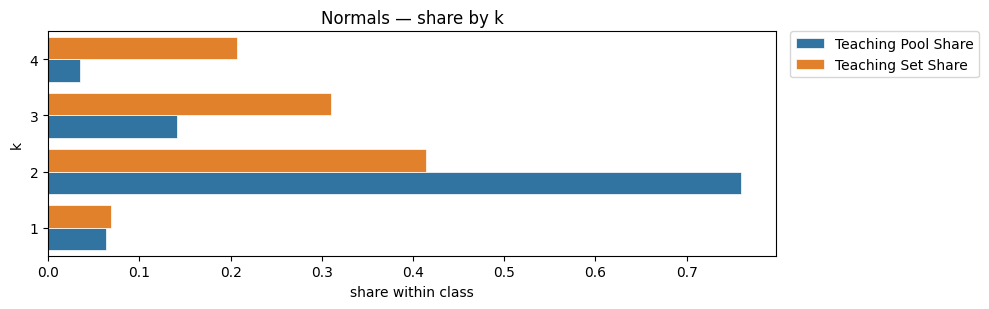

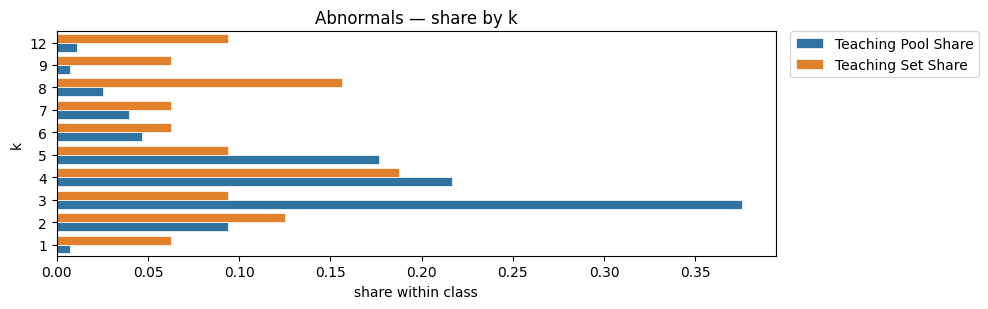

In [10]:
# builds summary tables
from mt4xai.teach import selection_vs_pool_report

rep = selection_vs_pool_report(pool.bins_df, s.teaching_set_df)
print("\nTeaching Pool share vs Teaching Set share")

def plot_teaching_share_by_k(
    by_k_df: pd.DataFrame,
    *,
    class_names: dict[int, str] | None = None,
    palette: dict[str, str] | None = None,
    figsize: tuple[float, float] = (10.0, 3.2),
    bar_height: float = 0.6,
    legend_outside: bool = True,
) -> list[tuple[Figure, Axes]]:
    """Draws horizontal bar charts of share-by-k for pool vs selection, one figure per class.

    Converts the wide summary table (with columns like 'share_in_class_pool' and
    'share_in_class_sel') to long form and plots a grouped horizontal bar chart
    per class. Bars are ordered by ascending k and use Seaborn's categorical
    plotting for clear comparison of discrete segment counts.

    Args:
        by_k_df: Per-class summary with columns ['class_label', 'k',
            'share_in_class_pool', 'share_in_class_sel'].
        class_names: Optional mapping from class id (e.g. 0/1) to display name
            (e.g. {"0": "Normal", "1": "Abnormal"} or {0: "Normal", 1: "Abnormal"}).
        palette: Optional colour mapping for the two sources. Keys must match
            {'Teaching Pool Share', 'Teaching Set Share'}.
        figsize: Matplotlib figure size (width, height) for each class figure.
        bar_height: Height of each bar for a single hue; adjust for spacing.
        legend_outside: If True, places the legend to the right of the axes.

    Returns:
        list of (Figure, Axes) tuples, one per class label in ascending order.
    """
    # tidy names for the two series
    rename_cols = {
        "share_in_class_pool": "Teaching Pool Share",
        "share_in_class_sel": "Teaching Set Share",
    }
    if palette is None:
        # default to a simple, readable palette
        palette = {
            "Teaching Pool Share": sns.color_palette()[0],
            "Teaching Set Share": sns.color_palette()[1],
        }

    figs_axes: list[tuple[Figure, Axes]] = []
    classes = sorted(by_k_df["class_label"].unique())

    for c in classes:
        d = by_k_df[by_k_df["class_label"] == c].copy()
        d = d.rename(columns=rename_cols)

        # melt to long form for seaborn (source vs share)
        long = d.melt(
            id_vars=["k"],
            value_vars=list(rename_cols.values()),
            var_name="Source",
            value_name="Share",
        )

        # ensure discrete ordering by k
        k_order = sorted(d["k"].unique())
        long["k"] = pd.Categorical(long["k"], categories=k_order, ordered=True)

        fig, ax = plt.subplots(figsize=figsize)
        sns.barplot(
            data=long,
            y="k",
            x="Share",
            hue="Source",
            orient="h",
            dodge=True,
            ax=ax,
            palette=palette,
            errorbar=None,
            linewidth=0.5,
            edgecolor="white",
        )

        # style
        disp_name = (
            class_names.get(c, str(c)) if isinstance(class_names, dict) else f"class {c}"
        )
        ax.set_title(f"{disp_name} — share by k")
        ax.set_xlabel("share within class")
        ax.set_ylabel("k")
        ax.set_ylim(-0.5, len(k_order) - 0.5)

        # consistent bar thickness
        for ccoll in ax.containers:
            try:
                ccoll.set_height(bar_height)
            except Exception:
                pass

        # legend placement
        if legend_outside:
            leg = ax.legend(
                title=None,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0.0,
                frameon=True,
            )
            fig.tight_layout()
        else:
            ax.legend(frameon=True)
            fig.tight_layout()

        figs_axes.append((fig, ax))

    return figs_axes


# from mt4xai.plot import plot_teaching_share_by_k
_ = plot_teaching_share_by_k(
    rep["by_k"],
    class_names={0: "Normals", 1: "Abnormals"},
    figsize=(10, 3.2),
    legend_outside=True,
)

print("Per-class, per-k comparison:")
display(
    rep["by_k"]
      .assign(selection_rate=lambda d: d["selection_rate"].round(3),
              lift=lambda d: d["lift"].round(3))
      .sort_values(["class_label", "k"])
      .reset_index(drop=True)
)

print("\nPer-class, per-k-bin comparison:")
display(
    rep["by_k_bin"]
      .assign(selection_rate=lambda d: d["selection_rate"].round(3),
              lift=lambda d: d["lift"].round(3))
      .sort_values(["class_label", "k_bin_label"])
      .reset_index(drop=True)
)

print("\nExtremes summary: (min/max k and rarest k per class in the pool)")
display(rep["extremes_summary"])

### 4 - The Teaching Session: Serving examples from the teaching set <a id="teaching"></a>
The user study has three trial groups. All groups sample from the same teaching set, i.e. the same charging session IDs. The nature and ordering of examples differ:

- **Group A** (explanations with curriculum): order by `k_power↑` then `margin_power↓`, overlay raw power with simplification and show simplified SOC. 
- **Group B** (explanations, no curriculum): random order, overlay raw power with simplification and show simplified SOC. 
- **Group C** (control, no explanations): random order, raw power and SOC only (no simplifications).

Constructing the teaching set is computationally expensive and the optimal teaching set for explaining the time series classifier (TSC) is large. 
We therefore cap the teaching set at most 100 per class by default to limit the computational effort required to build it. 

In [11]:
# serves without pre-capping and applies post-order cap when exporting
s.build_group_iterators()  # no cap here anymore

# Create the Teaching Set and examples for trial groups A, B, C
examples = s.serve_examples(
    group="All",
    plot_examples=False,
    n=EXAM_SET_EX_PER_CLS*2,  # num examples to serve
    save_dir=TEACHING_SET_DIR,
    show_meta=False,
)
# The teaching sessions alterate between normal and abnormal examples. 
print(f"{len(examples["A"])} examples saved in {TEACHING_SET_DIR}/A")
print(f"{len(examples["B"])} examples saved in {TEACHING_SET_DIR}/B")
print(f"{len(examples["C"])} examples saved in {TEACHING_SET_DIR}/C")

40 examples saved in /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/teaching_sets/A
40 examples saved in /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/teaching_sets/B
40 examples saved in /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/teaching_sets/C


----------------  Teaching Set A  ----------------
Classification label: normal, k: 1, session ID: 9997120


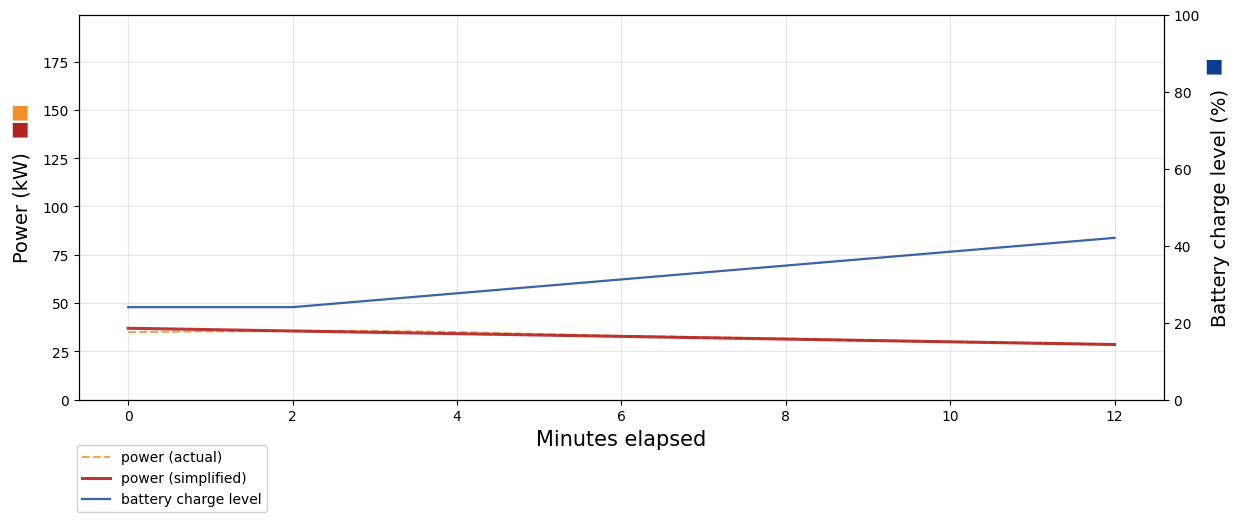

Classification label: abnormal, k: 12, session ID: 7075532


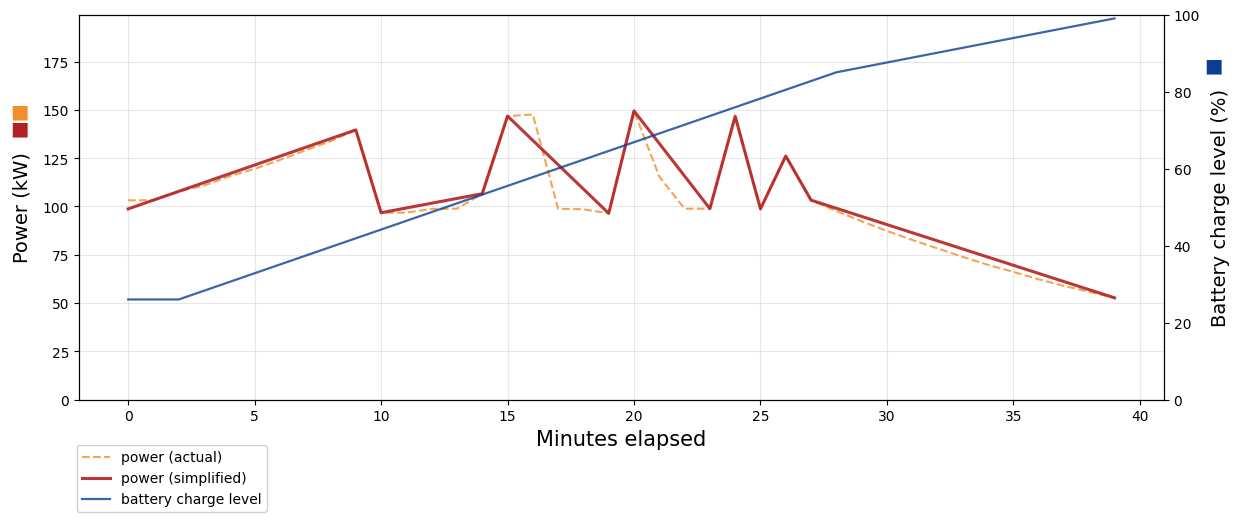

Classification label: normal, k: 1, session ID: 606983


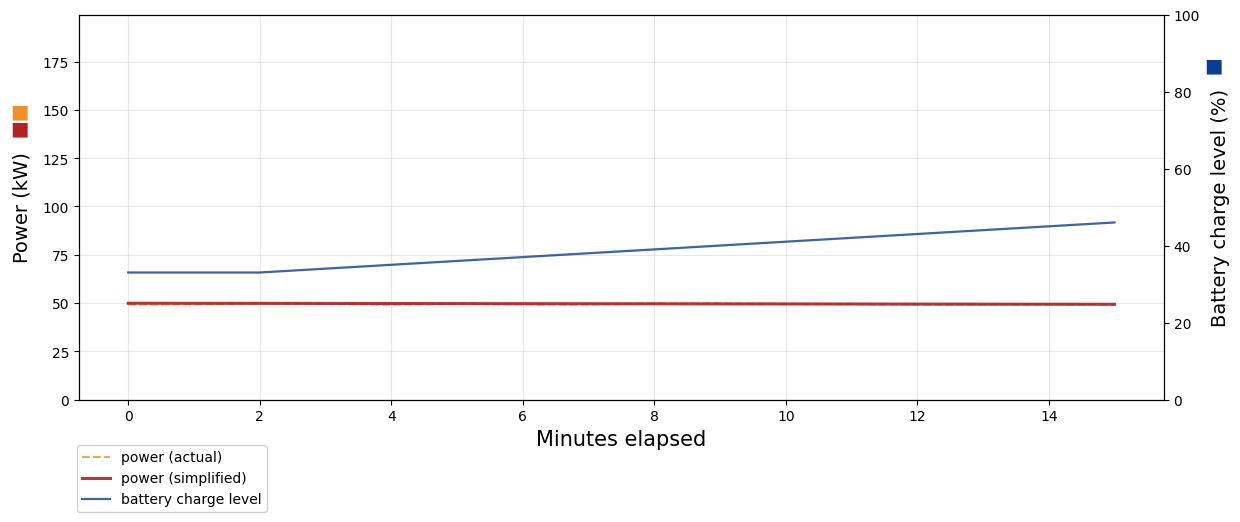

Classification label: abnormal, k: 12, session ID: 4722266


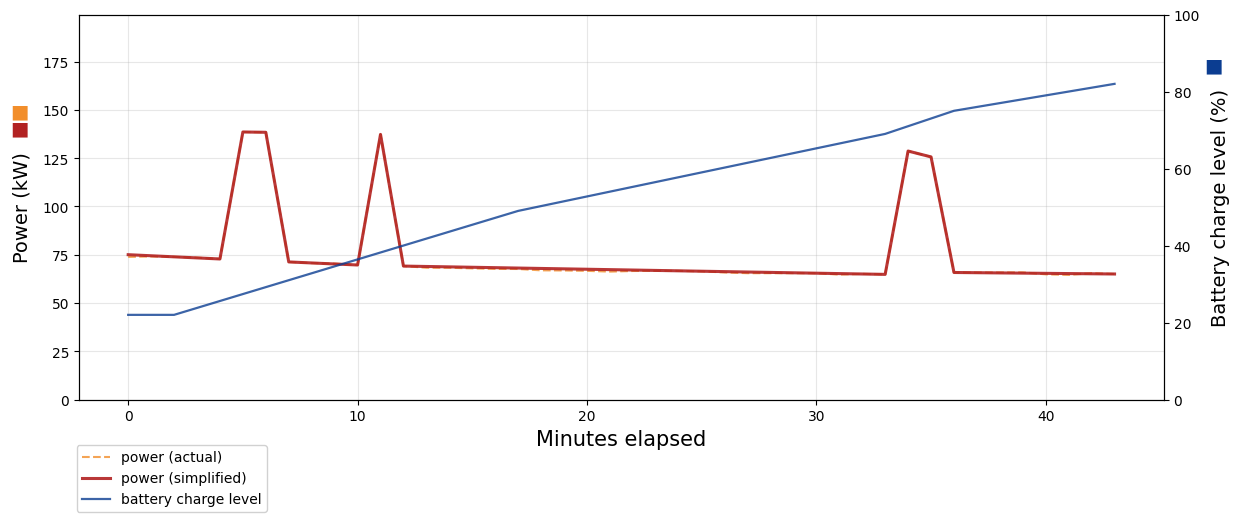

Classification label: normal, k: 2, session ID: 11672841


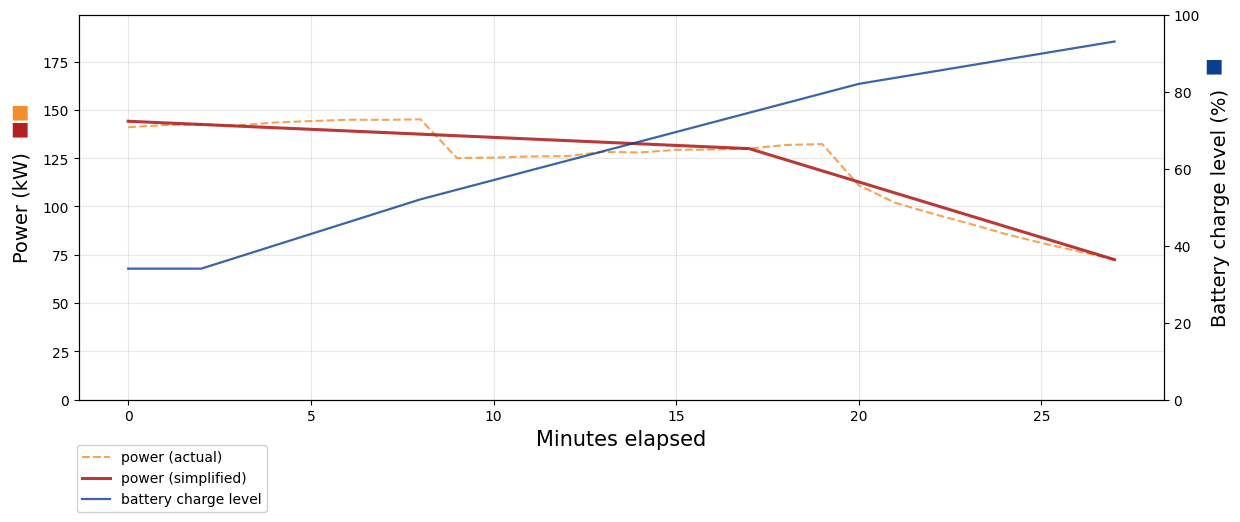

Classification label: abnormal, k: 12, session ID: 11897769


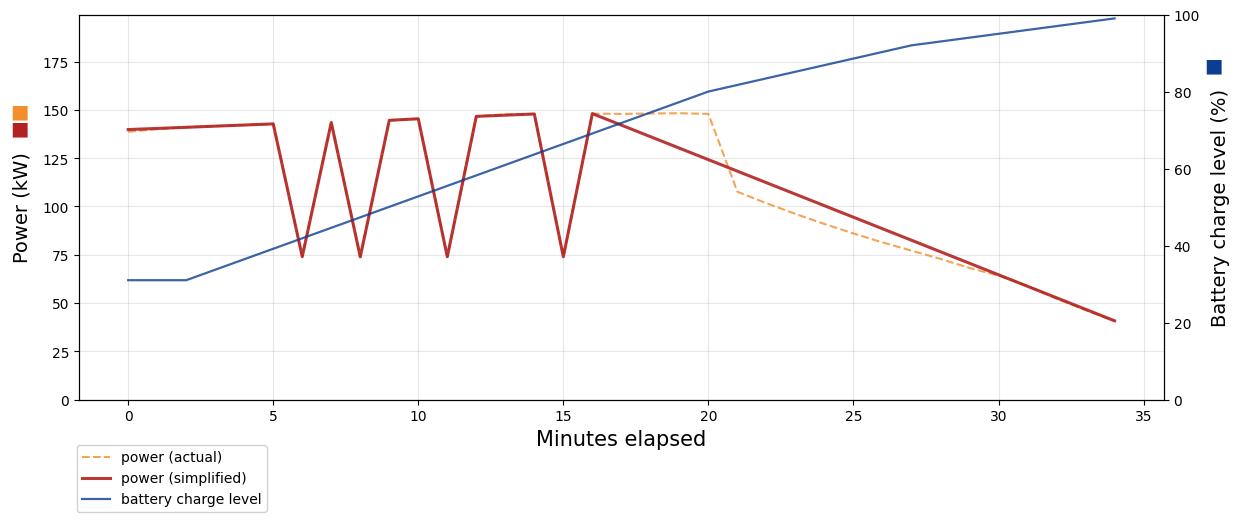

In [12]:
# Plot a few examples from the Teaching Set
s.build_group_iterators()  # resets the iterators (same order but restart from first example per set)
_ = s.serve_examples(
    group="A",
    plot_examples=True,
    n=6,
    save_dir=None,
    show_meta=False,
)

### 5- Constructing Exam Sets $E_1$, $E_2$ for Experiments

In [13]:
construct_pool = False  # if False, will look for existing pool and resume existing/start from scratch if not complete
EXAM_SAMPLE_PLAN = EXAM_POOL_DIR / "sampled_normals.json"

# configures the teaching pool with the same ORS and pool parameters as before
examtpconfig = TeachingPoolConfig(
    model_path=MODEL_FP, 
    output_dir=EXAM_POOL_DIR,
    ad_threshold=AD_THRESHOLD,  # we reuse the same AD threshold (95th percentile) as before, so the AI still "behaves" similarly
    random_seed=RANDOM_SEED,
    length_range=(11, 60),  # only samples sequences in range [min_T, max_T]
    device=DEVICE,
    export_every=10,
    L=128, P=4,   # for embeddings 
    decay_lambda=cfg.inference.horizon_decay_lambda,
    ors_params=ORSParams(
        stage1_mode="dp_prefix", 
        stage2_err_metric="rmse",
        dp_q=300,
        rdp_stage1_candidates=50,
        dp_alpha=0.0075, 
        beta=4.0, 
        gamma=0.05,
        R=3500,
        epsilon_mode="fraction", 
        epsilon_value=0.2,
        t_min_eval=2, 
        anchor_endpoints="last", 
        min_k=1, max_k=12, 
        random_seed=RANDOM_SEED,
        soc_stage1_mode="rdp", 
        soc_rdp_epsilon=0.75,
        model_id=MODEL_FP
    )
)

if EXAM_POOL_PATH.exists():
    print("Loaded previously computed teaching exam_pool from disk")
    exam_pool = TeachingPool.load_from_parquet(EXAM_POOL_PATH, config=examtpconfig)
    n_current_abn = int((exam_pool.pool_df["label_int"] == 1).sum())
    n_current_norm = int((exam_pool.pool_df["label_int"] == 0).sum())
    print(f"Current pool counts: {n_current_abn} abn, {n_current_norm} norm")

    counts = _sampling_plan_counts(EXAM_SAMPLE_PLAN)
    if counts is not None:
        target_abn, target_norm = counts
        print(f"Target counts: {target_abn} abn, {target_norm} norm")
        if n_current_abn >= target_abn and n_current_norm >= target_norm:
            construct_pool = False
        else:
            construct_pool = True
    else:
        construct_pool = True
else:
    construct_pool = True


if construct_pool:
    print("Building / updating teaching pool for exam set construction...")
    exam_pool = TeachingPool.construct_from_cfg(
        model=model,
        config=examtpconfig,
        loader=test_loader, # *test* tensor data for inference
        df_scaled=test_s,  # *test* DataFrame for plotting & ORS
        power_scaler=power_scaler,
        soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp,
        idx_soc_inp=idx_soc_inp,
    )

exam_pool.describe()

Loaded previously computed teaching exam_pool from disk
Current pool counts: 538 abn, 529 norm
Target counts: 551 abn, 551 norm
Building / updating teaching pool for exam set construction...
[teaching_pool] computing base labels...
[teaching_pool] targets: 551 abnormals, 551 normals (base candidates: 551 abn, 11632 norm)
[teaching_pool] cached counts: 538 abn, 529 norm. remaining targets: 13 abn, 22 norm.
[teaching_pool] processing queue size: 35
[ORS][warn] sid=5080852 no valid candidates after constraints (mode=dp_prefix, k_span=1..3, dp_q=11, beta=4.0). Trying fallback #1.
[ORS][warn] sid=5080852 still no valid candidates (fb#1 k_span=1..3, dp_q=22, beta=16.0). Trying fallback #2 (rdp).
[ORS][warn] sid=5080852 fallbacks exhausted (rdp k_span=1..9); skipping session.
[teaching_pool][warn] skipping sid=5080852: res_not_dict
[teaching_pool] processed 10/35 sessions in 1.2 min
[teaching_pool] processed 20/35 sessions in 2.3 min
[teaching_pool] build complete. processed 22/35 sessions. a

In [15]:
# derive per-bin budgets from the exam pool. Total examples in S = 2 x TEACHING_SET_EX_PER_CLASS
bins_df_exam, bins_meta_exam = exam_pool.bin_pool(
    label_source="base",
    binning="fixed",
    target_bins=5, min_bins=4, max_bins=6,
    fixed_edges_per_class=None,
    ensure_extrema=True, save_outputs=True, verbose=True
)

per_bin_budget = exam_pool.derive_per_bin_budget(per_class_target=EXAM_SET_EX_PER_CLS+14, bin_allocation="even")
print(per_bin_budget)


print(bins_df_exam.head(20))

rows in pool: 1089
class 0:
  unique k: 5  range: [1,5]
  k counts: {1: 25, 2: 413, 3: 90, 4: 22, 5: 1}
  bins (4): labels=[1, 2, 3, 4, 5]  counts=[438, 90, 22, 1]
class 1:
  unique k: 12  range: [1,12]
  k counts: {1: 6, 2: 45, 3: 196, 4: 105, 5: 103, 6: 51, 7: 13, 8: 9, 9: 5, 10: 1, 11: 2, 12: 2}
  bins (5): labels=[1, 4, 6, 8, 10, 12]  counts=[247, 208, 64, 14, 5]
{'0': {'[1, 2]': 9, '[2, 3]': 9, '[3, 4]': 8, '[4, 5]': 8}, '1': {'[1, 4]': 7, '[4, 6]': 7, '[6, 8]': 7, '[8, 10]': 7, '[10, 12]': 6}}
    session_id  class_label  k  k_bin_idx k_bin_label  label_int label_text  \
0       104847            0  2          0      [1, 2]          0     normal   
1       119168            0  2          0      [1, 2]          0     normal   
2       167874            1  3          0      [1, 4]          1   abnormal   
3       175219            0  2          0      [1, 2]          0     normal   
4       179353            0  2          0      [1, 2]          0     normal   
5       231570       

In [16]:
# Summary statistics
exam_pool.describe()
display(exam_pool.pool_df.head())
print("Frequencies of k for normal sessions in the exam pool:")
print(exam_pool.pool_df[exam_pool.pool_df["label_text"] == "normal"]["k"].value_counts())
print("Frequencies of k for abnormal sessions in the exam pool:")
print(exam_pool.pool_df[exam_pool.pool_df["label_text"] == "abnormal"]["k"].value_counts())

[teaching pool] rows=1089, classes:
label_int
0    551
1    538

[k] stats:
 count    1089.000000
mean        3.124885
std         1.521602
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        12.000000

[bins] counts per (class, k_bin_label):
label_int      0    1
k_bin_label          
[1, 2]       438    0
[1, 4]         0  247
[10, 12]       0    5
[2, 3]        90    0
[3, 4]        22    0
[4, 5]         1    0
[4, 6]         0  208
[6, 8]         0   64
[8, 10]        0   14


,session_id,label_text,label_int,k,err,frag,robust_prob,margin,threshold,model_id,ts_unix,sts_full_path,piv_path,emb_dim,emb,raw_power_path,raw_soc_path,piv_soc_path,sts_soc_path
0,104847,normal,0,2.0,5.208522,0.000000,1.000000,8.133778,13.3423,final_model.pth,1.763556e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_s...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_p...,264,"[-1.8264236450195312, -1.7963963747024536, -1.766369104385376, -1.736341953277588, -1.7063146829605103, -1.676287412...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_r...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...
1,119168,normal,0,2.0,1.092327,0.000000,1.000000,12.249973,13.3423,final_model.pth,1.763556e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_s...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_p...,264,"[0.3210545778274536, 0.3321238160133362, 0.34319305419921875, 0.3542622923851013, 0.3653315305709839, 0.376400768756...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_r...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...
2,167874,abnormal,1,3.0,19.475798,0.000000,1.000000,-6.133498,13.3423,final_model.pth,1.763556e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_s...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_p...,264,"[0.4949926733970642, 0.4946686625480652, 0.49434465169906616, 0.49402064085006714, 0.4936966001987457, 0.49337258934...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_r...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...
3,175219,normal,0,2.0,4.971014,0.000000,1.000000,8.371286,13.3423,final_model.pth,1.763567e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_s...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_p...,264,"[-0.0662524625658989, -0.06076214462518692, -0.055271830409765244, -0.04978151246905327, -0.04429119452834129, -0.03...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/power_r...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...
4,179353,normal,0,2.0,7.534482,0.130571,0.869429,5.8

Frequencies of k for normal sessions in the exam pool:
k
2.0    413
3.0     90
1.0     25
4.0     22
5.0      1
Name: count, dtype: int64
Frequencies of k for abnormal sessions in the exam pool:
k
3.0     196
4.0     105
5.0     103
6.0      51
2.0      45
7.0      13
8.0       9
1.0       6
9.0       5
12.0      2
11.0      2
10.0      1
Name: count, dtype: int64


In [17]:
e = TeachingSet(
    exam_pool,
    per_bin_budget=per_bin_budget,
    per_class_target=None, 
    bin_allocation="even",  # enforce even selection across k bins
    enforce_even_class_dist=True, # stops both classes when one hits its achievable limit
    lambda_margin=0.10,
    lambda_robust=0.05,
    lazy_prune=True,
    random_seed=RANDOM_SEED,
    min_per_k=2,  # Enforce selection >= 2 of each k value so whole dist of k is represented
    output_dir=EXAM_POOL_DIR,
)

e.save(output_dir=EXAM_POOL_DIR)

[teach] selection complete.
  class 0: selected=20 | F(S)=534.5221
  class 1: selected=20 | F(S)=314.8785
  wrote → /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/selection.parquet
  wrote → /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/selection_config.json


In [18]:
e.describe()
display(e.teaching_set_df.head())

[teaching set] rows=40, classes:
class_label
0    20
1    20

[coverage] facility-location by class:
  class 0: 534.5221
  class 1: 314.8785

[per-bin selected] counts by class:
  class 0: {'[1, 2]': 9, '[2, 3]': 9, '[3, 4]': 1, '[4, 5]': 1}
  class 1: {'[1, 4]': 5, '[4, 6]': 5, '[6, 8]': 4, '[8, 10]': 3, '[10, 12]': 3}


,session_id,class_label,k,k_bin_idx,k_bin_label,label_int,label_text,robust_prob,margin,threshold,...,raw_soc_path,sts_soc_path,piv_soc_path,model_id,gain_coverage,score_total,rank_in_bin,rank_in_class,k_bin,chosen_neighbors
0,7193703,0,2,0,"[1, 2]",0,normal,1.0,13.033168,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,final_model.pth,213.043869,214.397186,1,1,"[1, 2]","[7193703, 10475246, 3625233, 6162927, 10661918]"
1,10475246,0,2,0,"[1, 2]",0,normal,1.0,5.923087,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,final_model.pth,0.367786,1.010094,2,2,"[1, 2]","[10475246, 7193703, 3625233, 6162927, 10661918]"
2,10174238,0,1,0,"[1, 2]",0,normal,1.0,12.815372,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,final_model.pth,8.717889,10.049426,3,3,"[1, 2]","[11969665, 11153931, 3085027, 10174238, 7723270]"
3,3487061,0,1,0,"[1, 2]",0,normal,1.0,11.248905,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,final_model.pth,0.000000,1.174890,4,4,"[1, 2]","[11969665, 11153931, 3085027, 10174238, 7723270]"
4,9288579,0,2,0,"[1, 2]",0,normal,1.0,12.636945,13.3423,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_raw...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_sts...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/exam_teaching_pool/soc_piv...,final_model.pth,166.129669,167.443364,5,5,"[1, 2]","[9288579, 2212724, 7555225, 9601958, 9434752]"


In [19]:
exam_meta = e.construct_exam_sets(
    per_set_total=20,
    output_dir=EXAM_SET_DIR,
    random_seed=RANDOM_SEED,
    save_images=True,
    image_format="png",
)

print("Exam sets written:")
print(exam_meta["paths"])

Exam sets written:
{'set1': {'A_raw': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set1/A/raw', 'A_overlay': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set1/A/overlay', 'B_raw': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set1/B/raw', 'B_overlay': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set1/B/overlay', 'C_raw': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set1/C/raw'}, 'set2': {'A_raw': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set2/A/raw', 'A_overlay': '/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Figures/exam_sets/set2/A/overlay', 'B_raw': '/home/srokholt/Masters_Project_Linux_Env/Mach